# Vintage Resale Business - Data Analysis (2021-2025)

**Author:** Richard Rowe
**Skills:** Python · pandas · matplotlib · seaborn · pdfplumber · data cleaning
**GitHub:** [rrowe99](https://github.com/rrowe99)

---

I've been buying and reselling products online since 2021. What started with sneakers, Pokémon cards, and even crypto mining equipment gradually evolved into a vintage clothing and workwear business sold through eBay, Depop, Grailed, Instagram, and in person flea markets throughout New England.

This notebook turns five years of messy raw data (1099-K tax forms, marketplace CSV exports, handwritten market notes, and expense records) into a clean, visual business analysis.

**Questions this notebook answers:**
1. How did the business grow, and where did the money come from?
2. When do sales  happen? (online seasonality vs. market season)
3. Which sales channel is worth it? (price, fees, and take home by platform)
4. What actually makes money? (top items and 2022 item level ROI)
5. Is the business profitable? (revenue vs. expenses, 2024-2025)
6. Data limitations
7. Key takeaways & business implications

## Setup

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Data parsers (from src/parse_data.py)
from parse_data import (
    parse_item_csvs, parse_1099s, 
    build_annual_summary, build_expenses, build_market_events,
    parse_ebay_transactions, parse_depop_sales, build_notable_items
)

# Styling
PALETTE = {
    "ebay":     "#E53238",
    "grailed":   "#1B1B1B",
    "depop":     "#FF2300",
    "market":    "#4A90D9",
    "instagram": "#C13584",
}
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "font.size": 11})
print("✅ Imports ready")

✅ Imports ready


## Data Sources

The raw data comes from four different source types:
- **CSV exports**: Flyp inventory tracker (2022), eBay Seller Hub, and Depop seller dashboard
- **1099-K PDFS**: IRS tax forms; monthly revenue is extracted with 'pdfplumber' and regular expressions
- **Handwritten market notes**: transcribed by hand into a structured event log
- **Expense summaries**: annual expense breakdowns

A large part of this project was cleaning and standardizing these sources before any analysis could be done. All extraction logic lives in 'src/parse_data.py'

In [2]:
# Load all datasets
items   = parse_item_csvs()            # 2022 item level sales (Flyp)
ebay_tx = parse_ebay_transactions()     # eBay orders 2024-2025
depop_tx = parse_depop_sales()          # Depop sales 2023-2025
monthly = parse_1099s()                 # monthly 1099-K revenue by platform
annual = build_annual_summary()         # annual totals by platform
expenses = build_expenses()             # expense categories by year
markets = build_market_events()         # in person market events

print(f"\nItems (2022):     {len(items)} sold items")
print(f"eBay transactions:  {len(ebay_tx)} orders | avg ${ebay_tx['revenue'].mean():.2f}")
print(f"Depop transactions: {len(depop_tx)} sales | avg ${depop_tx['revenue'].mean():.2f}")
print(f"Monthly revenue:    {len(monthly)} platform-months")
print(f"Annual summary:     {annual['year'].nunique()} years, {annual['platform'].nunique()} platforms")
print(f"Market events:      {len(markets)} events")

  ✓ Flyp CSVs: 59 sold items
  ✓ Transaction_report_20240101_20240331.csv: 11 orders
  ✓ Transaction_report_20240401_20240630.csv: 33 orders
  ✓ Transaction_report_20240701_20240930.csv: 27 orders
  ✓ Transaction_report_20241001_20241231.csv: 20 orders
  ✓ Transaction_report_20250101_20250331.csv: 36 orders
  ✓ Transaction_report_20250401_20250630.csv: 25 orders
  ✓ Transaction_report_20250701_20250930.csv: 38 orders
  → eBay total: 190 orders
  ✓ Depop Sales 02_01_2023 - 04_01_2023.csv: 13 sales
  ✓ Depop Sales 03_01_2024 - 05_29_2024.csv: 94 sales
  ✓ Depop Sales 04_01_2023 - 06_30_2023.csv: 23 sales
  ✓ Depop Sales 06_01_2024 - 08_31_2024.csv: 53 sales
  ✓ Depop Sales 07_01_2023 - 09_30_2023.csv: 20 sales
  ✓ Depop Sales 09_01_2024 - 11_30_2024.csv: 11 sales
  ✓ Depop Sales 10_01_2023 - 12_30_2023.csv: 77 sales
  ✓ Depop Sales 12_01_2023 - 02_29_2024.csv: 73 sales
  ✓ Depop Sales 12_01_2024 - 02_28_2025.csv: 14 sales
  → Depop total: 378 sales
 ✓ Paypal_1099K_2022.pdf: 11 months
 ✓ 

## 1. How did the business grow, and where did the money come from?

The business changed a lot over five years:
- **2021:** Sneakers and collectibles on eBay, before the vintage focus
- **2022:** Grailed (via Paypal) as the main channel; started new eBay in October
- **2023:** eBay became the main online channel; added Depop
- **2024:** First full season of in person flea markets
- **2025:** eBay grew; Depop wound down; the best single market day (Brimfield, May)

In [4]:
# Annual totals at a glance
summary = annual.groupby("year")["gross_revenue"].sum().reset_index()
summary.columns = ["Year", "Gross Revenue"]
summary["YoY Growth"] = summary["Gross Revenue"].pct_change().mul(100).round(1).astype(str) + "%"
summary["Gross Revenue"] = summary["Gross Revenue"].map("${:,.2f}".format)
print("=== Annual Revenue Summary ===")
display(summary)

=== Annual Revenue Summary ===


,Year,Gross Revenue,YoY Growth
0,2021,"$9,149.72",NaN
1,2022,"$8,265.94",-9.7%
2,2023,"$19,963.31",141.5%
3,2024,"$36,274.12",81.7%
4,2025,"$31,021.61",-14.5%


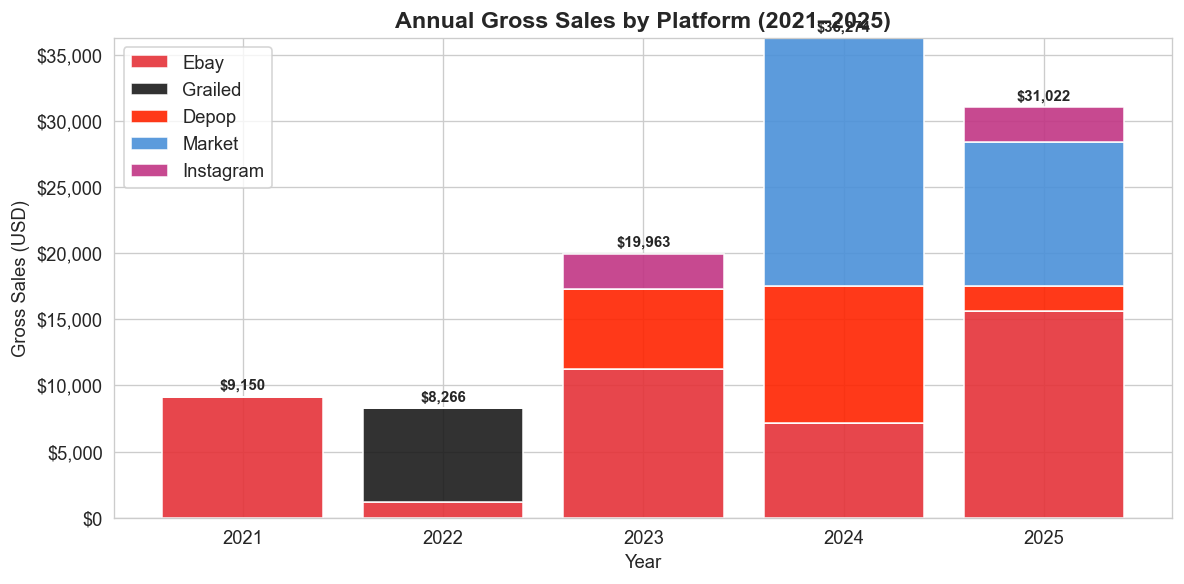

In [5]:
pivot = annual.pivot_table(
    index="year", columns="platform", values="gross_revenue", aggfunc="sum"
).fillna(0)

fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(pivot))
for plat, color in PALETTE.items():
    if plat in pivot.columns:
        ax.bar(pivot.index.astype(str), pivot[plat], bottom=bottom,
               label=plat.title(), color=color, alpha=0.9, edgecolor="white")
        bottom += pivot[plat].values

for i, total in enumerate(bottom):
    ax.text(i, total + 300, f"${total:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Annual Gross Sales by Platform (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../images/01_annual_sales_by_platform.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Group platforms into two channels: online marketplaces vs. in person (markets + Instagram contacts)
annual["channel"] = np.where(annual["platform"].isin(["market", "instagram"]), "In-person", "Online")

channel = annual.pivot_table(
    index="year", columns="channel", values="gross_revenue", aggfunc="sum"
).fillna(0)
channel["In-person %"] = channel["In-person"] / (channel["In-person"] + channel["Online"]) * 100

formatted = channel.copy()
formatted["Online"]      = formatted["Online"].map("${:,.0f}".format)
formatted["In-person"]   = formatted["In-person"].map("${:,.0f}".format)
formatted["In-person %"] = formatted["In-person %"].map("{:.1f}%".format)
display(formatted)

channel,In-person,Online,In-person %
year,,,
2021,$0,"$9,150",0.0%
2022,$0,"$8,266",0.0%
2023,"$2,700","$17,263",13.5%
2024,"$18,800","$17,474",51.8%
2025,"$13,500","$17,522",43.5%


In [7]:
# Break online sales into volume x price
online = annual[annual["channel"] == "Online"].groupby("year").agg(
    sales=("gross_revenue", "sum"),
    transactions=("num_transactions", "sum"),
)
online["avg_per_sale"] = online["sales"] / online["transactions"]

formatted = online.copy()
formatted["sales"]        = formatted["sales"].map("${:,.0f}".format)
formatted["avg_per_sale"] = formatted["avg_per_sale"].map("${:,.0f}".format)
display(formatted)

,sales,transactions,avg_per_sale
year,,,
2021,"$9,150",33,$277
2022,"$8,266",59,$140
2023,"$17,263",178,$97
2024,"$17,474",303,$58
2025,"$17,522",185,$95


**Finding:**
- **Online sales were flat (~$17.5k/year, 2023–2025), but the online business model changed.** 2024 ran on volume (303 sales averaging $58, driven by Depop); 2025 brought in the same money from 118 fewer sales averaging $95 (driven by eBay). Fewer, higher value sales means less time spent listing, packing, and shipping for the same revenue.
- **Nearly all growth after 2023 came from in person selling**, rising from $2.7k in 2023 to $18.8k in 2024, more than half of that year's sales.
- **Average sale price tells the story of the pivot**: $277 in 2021 (sneakers) down to $58–$97 as the business shifted to vintage clothing.

*Note: 2021 reflects a different product mix (sneakers/collectibles), and 2022 eBay covers only Oct–Dec, so growth from 2021–2022 isn't a like-for-like comparison.*